# Multi-Dataset Ultrasound CLIP Contrastive Learning

This notebook trains and evaluates CLIP-style image-text alignment across multiple ultrasound datasets.

## Sections
1. **Configuration** — all paths and hyperparameters in one place
2. **Data Loading** — auto-detect CSV columns, verify image paths, print load summary
3. **Train/Val/Test Split** — stratified by dataset source
4. **Dataset & DataLoaders**
5. **Model Definitions** — EchoCare image encoder + CLIP text encoder
6. **t-SNE: Image Embedding Space** — colored by dataset, cluster center images
7. **t-SNE: Text Caption Space** — colored by dataset, cluster center captions
8. **Training Experiments** — Baseline / MLP only / MLP+ImgEnc / MLP+TxtEnc
9. **Results** — alignment score comparison bar plot + training curves

---
## Section 0 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
!pip install -q monai torch torchvision transformers einops matplotlib scikit-learn tqdm pandas Pillow scipy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import CLIPTokenizer, CLIPTextModel
from monai.networks.nets.swin_unetr import SwinTransformer

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

---
## Section 1 — Configuration

**Edit all paths and hyperparameters here.** Nothing else in the notebook needs to change.

In [ ]:
config = {
    # ── Paths ──────────────────────────────────────────────────────────────
    # Root folder containing one subfolder per dataset, each with a .csv
    'prepared_data_root': '/content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data',
    # TODO: update to your EchoCare checkpoint path
    'echocare_checkpoint': '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth',

    # ── Image Encoder (EchoCare SwinTransformer) ───────────────────────────
    'feature_size'   : 128,   # SwinTransformer base channel dim
    'in_channels'    : 3,     # RGB
    'image_size'     : 256,   # H = W

    # ── Text Encoder (CLIP) ────────────────────────────────────────────────
    'clip_model_name': 'openai/clip-vit-base-patch32',
    'max_seq_len'    : 77,

    # ── Shared Latent Space ────────────────────────────────────────────────
    'projection_dim' : 256,

    # ── Normalization ──────────────────────────────────────────────────────
    # Default: ImageNet statistics (standard starting point for pretrained backbones).
    # To use train-set statistics instead, run the "Compute train-set normalization"
    # cell in Section 3 — it will overwrite these values in-place.
    'img_mean': [0.485, 0.456, 0.406],
    'img_std' : [0.229, 0.224, 0.225],

    # ── Data splits ────────────────────────────────────────────────────────
    'test_size'  : 0.15,
    'val_size'   : 0.15,
    'random_seed': 42,

    # ── Training ───────────────────────────────────────────────────────────
    'batch_size'      : 16,
    'num_epochs'      : 10,
    'lr'              : 1e-4,
    'weight_decay'    : 1e-4,
    'init_temperature': 0.07,
    'num_workers'     : 2,

    # ── Visualization ──────────────────────────────────────────────────────
    'tsne_perplexity'     : 30,
    'n_cluster_centers'   : 5,
    'n_captions_per_cluster': 3,
}

print('Configuration:')
for k, v in config.items():
    print(f'  {k:30s}: {v}')


Configuration:
  prepared_data_root            : /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data
  echocare_checkpoint           : /content/drive/MyDrive/BMI702 Project/echocare_encoder.pth
  feature_size                  : 128
  in_channels                   : 3
  image_size                    : 256
  clip_model_name               : openai/clip-vit-base-patch32
  max_seq_len                   : 77
  projection_dim                : 256
  img_mean                      : [0.485, 0.456, 0.406]
  img_std                       : [0.229, 0.224, 0.225]
  test_size                     : 0.15
  val_size                      : 0.15
  random_seed                   : 42
  batch_size                    : 16
  num_epochs                    : 10
  lr                            : 0.0001
  weight_decay                  : 0.0001
  init_temperature              : 0.07
  num_workers                   : 2
  tsne_perplexity               : 30
  n_cluster_centers             : 5
  n_capt

---
## Section 2 — Data Loading

Walks `prepared_data_root` to find all dataset folders containing a `.csv` file.
Auto-detects image path and caption column names (handles many naming conventions).
Resolves each image path using multiple fallback strategies and prints a load summary.

In [ ]:
def discover_datasets(root):
    """
    Walk the prepared_data root and return all (dataset_name, csv_path) pairs.
    A dataset folder is any directory that directly contains at least one .csv.
    If a folder has multiple CSVs, the largest one is used.
    """
    datasets = []
    for dirpath, dirnames, filenames in os.walk(root):
        csv_files = [f for f in filenames if f.lower().endswith('.csv')]
        if csv_files:
            dataset_name = os.path.basename(dirpath)
            # Pick largest CSV if multiple exist
            csv_full = [os.path.join(dirpath, f) for f in csv_files]
            csv_full.sort(key=os.path.getsize, reverse=True)
            datasets.append((dataset_name, csv_full[0]))
    return sorted(datasets)


datasets_found = discover_datasets(config['prepared_data_root'])
print(f'Found {len(datasets_found)} dataset(s) under: {config["prepared_data_root"]}\n')
for name, csv_path in datasets_found:
    print(f'  {name:40s}  ->  {csv_path}')

Found 5 dataset(s) under: /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data

  BrEaST-Lesions_USG-images_and_masks       ->  /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data/BrEaST-Lesions_USG-images_and_masks/captions.csv
  Dataset_BUSI_with_GT                      ->  /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data/Dataset_BUSI_with_GT/all_captions.csv
  Liver_ultrasound                          ->  /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data/Liver_ultrasound/captions.csv
  Lung_ultrasound                           ->  /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data/Lung_ultrasound/lung_captions.csv
  Thyroid                                   ->  /content/drive/MyDrive/BMI702 Project/ Ultrasound Data/prepared_data/Thyroid/thyroid_template_captions_with_paths.csv


In [ ]:
# ── Known column name variants (case-insensitive) ──────────────────────────────
PATH_COL_CANDIDATES    = ['file_name', 'image_name', 'path', 'filename',
                           'image_path', 'filepath', 'file', 'image',
                           'img_path', 'img', 'image_file']
CAPTION_COL_CANDIDATES = ['caption', 'text_caption', 'text_captions', 'description',
                           'text', 'label', 'report', 'finding', 'findings',
                           'annotation', 'sentence']


def detect_column(df_columns, candidates):
    """Return the first matching column name (case-insensitive), or None."""
    cols_lower = {c.lower(): c for c in df_columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def load_dataset_csv(csv_path, dataset_name):
    """
    Load a dataset CSV, auto-detecting path and caption columns.
    Returns a DataFrame with unified columns: image_path, caption, dataset.
    Raises ValueError with a helpful message if columns cannot be detected.
    """
    df = pd.read_csv(csv_path)

    path_col = detect_column(df.columns, PATH_COL_CANDIDATES)
    cap_col  = detect_column(df.columns, CAPTION_COL_CANDIDATES)

    if path_col is None:
        raise ValueError(
            f'[{dataset_name}] Cannot detect image path column.\n'
            f'  Available: {list(df.columns)}\n'
            f'  Expected one of: {PATH_COL_CANDIDATES}'
        )
    if cap_col is None:
        raise ValueError(
            f'[{dataset_name}] Cannot detect caption column.\n'
            f'  Available: {list(df.columns)}\n'
            f'  Expected one of: {CAPTION_COL_CANDIDATES}'
        )

    out = pd.DataFrame({
        'image_path': df[path_col].astype(str),
        'caption'   : df[cap_col].astype(str),
        'dataset'   : dataset_name,
    })
    print(f'  [{dataset_name}] {len(out)} rows | '
          f'path_col={path_col!r} | caption_col={cap_col!r}')
    return out


def resolve_image_path(raw_path, csv_dir):
    """
    Try multiple strategies to locate an image file.
    Returns the first existing resolved path, or None.

    Strategies (in order):
      1. raw_path as-is (absolute or cwd-relative)
      2. csv_dir / raw_path  (path relative to CSV folder)
      3. csv_dir / basename(raw_path)  (just the filename, in CSV folder)
      4. csv_dir / subdir / basename(raw_path)  for each immediate subdir
         — handles layouts like captions.csv sitting next to an image subfolder
           e.g. Liver_ultrasound/captions.csv + Liver_ultrasound/AULI_resized_images/liver_benign_1.png
    """
    basename = os.path.basename(raw_path)
    candidates = [
        raw_path,                                            # absolute or cwd-relative
        os.path.join(csv_dir, raw_path),                     # relative to CSV folder
        os.path.join(csv_dir, basename),                     # just filename in CSV folder
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p

    # One level deeper: search all immediate subdirectories of csv_dir
    try:
        for entry in os.scandir(csv_dir):
            if entry.is_dir():
                p = os.path.join(entry.path, basename)
                if os.path.isfile(p):
                    return p
                else:
                  p = os.path.join(entry.path, raw_path)
                  if os.path.isfile(p):
                    return p
    except OSError:
        pass

    return None

In [ ]:
# ── Load and verify every dataset ──────────────────────────────────────────────
all_dfs     = []
load_report = []  # list of (name, n_loaded, n_failed, status)

for dataset_name, csv_path in datasets_found:
    csv_dir = os.path.dirname(csv_path)

    # --- Load CSV ---
    try:
        df = load_dataset_csv(csv_path, dataset_name)
    except Exception as e:
        print(f'  [CSV ERROR] {dataset_name}: {e}')
        load_report.append((dataset_name, 0, 0, 'CSV_ERROR'))
        continue

    # --- Resolve image paths ---
    resolved, n_ok, n_fail = [], 0, 0
    for raw_path in df['image_path']:
        p = resolve_image_path(raw_path, csv_dir)
        resolved.append(p)
        if p is not None:
            n_ok += 1
        else:
            n_fail += 1

    df['resolved_path'] = resolved
    df_ok = df[df['resolved_path'].notna()].copy()
    df_ok['image_path'] = df_ok['resolved_path']
    df_ok = df_ok.drop(columns=['resolved_path'])

    if len(df_ok) > 0:
        all_dfs.append(df_ok)

    status = 'OK' if n_fail == 0 else f'{n_fail} missing'
    load_report.append((dataset_name, n_ok, n_fail, status))

# ── Print summary table ────────────────────────────────────────────────────────
print('\n' + '=' * 72)
print(f'{"Dataset":<38} {"Loaded":>8} {"Failed":>8}  Status')
print('=' * 72)
for name, n_ok, n_fail, status in load_report:
    ok_str   = f'{n_ok:,}'   if n_ok   else '-'
    fail_str = f'{n_fail:,}' if n_fail else '-'
    print(f'{name:<38} {ok_str:>8} {fail_str:>8}  {status}')
print('=' * 72)
total_ok   = sum(r[1] for r in load_report)
total_fail = sum(r[2] for r in load_report)
print(f'{"TOTAL":<38} {total_ok:>8,} {total_fail:>8,}')

  [BrEaST-Lesions_USG-images_and_masks] 248 rows | path_col='image_name' | caption_col='text_caption'
  [Dataset_BUSI_with_GT] 780 rows | path_col='image_path' | caption_col='text_caption'
  [Liver_ultrasound] 735 rows | path_col='file_name' | caption_col='caption'
  [Lung_ultrasound] 1062 rows | path_col='file_name' | caption_col='caption'
  [Thyroid] 2289 rows | path_col='image_name' | caption_col='text_caption'

Dataset                                  Loaded   Failed  Status
BrEaST-Lesions_USG-images_and_masks         248        -  OK
Dataset_BUSI_with_GT                        780        -  OK
Liver_ultrasound                            735        -  OK
Lung_ultrasound                           1,062        -  OK
Thyroid                                   2,289        -  OK
TOTAL                                     5,114        0


In [ ]:
# ── Combine into a single DataFrame ───────────────────────────────────────────
if not all_dfs:
    raise RuntimeError(
        'No data loaded successfully! '
        f'Check that prepared_data_root exists: {config["prepared_data_root"]}'
    )

full_df = pd.concat(all_dfs, ignore_index=True)[['image_path', 'caption', 'dataset']]

print(f'Combined dataset: {len(full_df):,} samples from {full_df["dataset"].nunique()} source(s)')
print('\nPer-dataset breakdown:')
counts = full_df['dataset'].value_counts()
for ds, n in counts.items():
    print(f'  {ds:<40} {n:>6,}  ({100*n/len(full_df):.1f}%)')

Combined dataset: 5,114 samples from 5 source(s)

Per-dataset breakdown:
  Thyroid                                   2,289  (44.8%)
  Lung_ultrasound                           1,062  (20.8%)
  Dataset_BUSI_with_GT                        780  (15.3%)
  Liver_ultrasound                            735  (14.4%)
  BrEaST-Lesions_USG-images_and_masks         248  (4.8%)


---
## Section 3 — Train / Val / Test Split

Stratified by `dataset` source so every dataset appears in all three splits proportionally.
Falls back to random split if any stratum is too small for stratification.

In [ ]:
# val_size as a fraction of the train+val remainder
val_frac = config['val_size'] / (1.0 - config['test_size'])

def safe_split(df, test_size, stratify_col, seed):
    """Train_test_split with stratification; falls back to random if strata too small."""
    try:
        return train_test_split(
            df, test_size=test_size,
            stratify=df[stratify_col], random_state=seed
        )
    except ValueError as e:
        print(f'  [WARNING] Stratified split failed ({e}). Using random split.')
        return train_test_split(df, test_size=test_size, random_state=seed)

train_val_df, test_df = safe_split(full_df, config['test_size'], 'dataset', config['random_seed'])
train_df,    val_df   = safe_split(train_val_df, val_frac,       'dataset', config['random_seed'])

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Split sizes  (total = {len(full_df):,})')
print(f'  Train : {len(train_df):>6,}  ({100*len(train_df)/len(full_df):.1f}%)')
print(f'  Val   : {len(val_df):>6,}  ({100*len(val_df)/len(full_df):.1f}%)')
print(f'  Test  : {len(test_df):>6,}  ({100*len(test_df)/len(full_df):.1f}%)')

Split sizes  (total = 5,114)
  Train :  3,579  (70.0%)
  Val   :    767  (15.0%)
  Test  :    768  (15.0%)


In [ ]:
# ── Compute train-set normalization statistics ────────────────────────────────
# Run this cell to replace the ImageNet defaults in config with statistics
# computed from YOUR training images.
# To revert to ImageNet normalization, comment out this entire cell.
# NOTE: must run BEFORE the Section 4 dataset / dataloader cells.

from torchvision import transforms as _T
from torch.utils.data import DataLoader as _DL, Dataset as _DS
from PIL import Image as _Image
import torch as _torch

class _RawTrainDataset(_DS):
    """Loads train images as tensors with NO normalization."""
    def __init__(self, df, image_size):
        self.paths = df['image_path'].tolist()
        self.tf = _T.Compose([
            _T.Resize(image_size),
            _T.CenterCrop(image_size),
            _T.ToTensor(),           # → [0, 1] float, shape (3, H, W)
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.tf(_Image.open(self.paths[idx]).convert('RGB'))

_raw_ds     = _RawTrainDataset(train_df, config['image_size'])
_raw_loader = _DL(_raw_ds, batch_size=64, num_workers=config['num_workers'],
                  pin_memory=False, shuffle=False)

_mean = _torch.zeros(3)
_var  = _torch.zeros(3)
_n    = 0

print(f'Computing mean and std over {len(_raw_ds):,} train images...')
for _imgs in _raw_loader:                     # (B, 3, H, W)
    B, C, H, W = _imgs.shape
    _pixels = _imgs.permute(1, 0, 2, 3).reshape(C, -1)   # (3, B*H*W)
    _mean  += _pixels.mean(dim=1)
    _var   += _pixels.var(dim=1)
    _n     += 1

_mean /= _n
_var  /= _n
_std   = _var.sqrt()

config['img_mean'] = _mean.tolist()
config['img_std']  = _std.tolist()

print(f'  mean : {[round(v, 4) for v in config["img_mean"]]}')
print(f'  std  : {[round(v, 4) for v in config["img_std"]]}')
print('config["img_mean"] and config["img_std"] updated.')


Computing mean and std over 3,579 train images...
  mean : [0.1948, 0.1974, 0.203]
  std  : [0.1949, 0.1972, 0.2024]
config["img_mean"] and config["img_std"] updated.


---
## Section 4 — Dataset & DataLoaders

In [ ]:
class MultiDatasetUltrasound(Dataset):
    """
    Multi-source ultrasound dataset with free-text captions.

    Returns per sample:
      image   : (3, image_size, image_size) float tensor, normalized
      caption : str  — clinical text description
      dataset : str  — source dataset name

    Transforms:
      train  — Resize(288) → RandomCrop(256) → RandomHorizontalFlip → ToTensor → Normalize
      val/test — Resize(256) → CenterCrop(256) → ToTensor → Normalize
    """

    def __init__(self, dataframe: pd.DataFrame, split: str = 'train', cfg: dict = config):
        self.df    = dataframe.reset_index(drop=True)
        self.split = split

        sz   = cfg['image_size']
        mean = cfg['img_mean']
        std  = cfg['img_std']

        if split == 'train':
            self.transform = transforms.Compose([
                transforms.Resize(int(sz * 1.125)),  # 288 for sz=256
                transforms.RandomCrop(sz),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(sz),
                transforms.CenterCrop(sz),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        image = self.transform(image)
        return image, row['caption'], row['dataset']


# Sanity check
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    ds = MultiDatasetUltrasound(df, split=split_name)
    img, cap, src = ds[0]
    print(f'[{split_name:5s}] image={tuple(img.shape)}  '
          f'dataset={src!r}  caption[:60]={cap[:60]!r}')

[train] image=(3, 256, 256)  dataset='Dataset_BUSI_with_GT'  caption[:60]='An ultrasound image of breast with benign findings.'
[val  ] image=(3, 256, 256)  dataset='BrEaST-Lesions_USG-images_and_masks'  caption[:60]='Ultrasound of breast with heterogeneous: predominantly fat t'
[test ] image=(3, 256, 256)  dataset='Liver_ultrasound'  caption[:60]='A clinical ultrasound scan of liver, indicative of benign pa'


In [ ]:
train_dataset = MultiDatasetUltrasound(train_df, split='train')
val_dataset   = MultiDatasetUltrasound(val_df,   split='val')
test_dataset  = MultiDatasetUltrasound(test_df,  split='test')

_loader_kw = dict(
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    pin_memory=True,
)

train_loader = DataLoader(train_dataset, shuffle=True,  drop_last=True,  **_loader_kw)
val_loader   = DataLoader(val_dataset,   shuffle=False, drop_last=False, **_loader_kw)
test_loader  = DataLoader(test_dataset,  shuffle=False, drop_last=False, **_loader_kw)

print('DataLoaders ready:')
print(f'  Train : {len(train_loader):>4} batches  ({len(train_dataset):,} samples)')
print(f'  Val   : {len(val_loader):>4} batches  ({len(val_dataset):,} samples)')
print(f'  Test  : {len(test_loader):>4} batches  ({len(test_dataset):,} samples)')

DataLoaders ready:
  Train :  223 batches  (3,579 samples)
  Val   :   48 batches  (767 samples)
  Test  :   48 batches  (768 samples)


---
## Section 5 — Model Definitions

```
Image: (B,3,256,256) → SwinTransformer → GAP → MLP → L2-norm → (B,256)
Text:  (B,77)        → CLIPTextModel   →       MLP → L2-norm → (B,256)
Loss:  symmetric InfoNCE (contrastive) with learnable temperature
```

In [ ]:
class EchoCareImageEncoder(nn.Module):
    """
    EchoCare SwinTransformer backbone + MLP projection head.

    Input  : (B, 3, 256, 256)
    Output : (B, projection_dim)  L2-normalized
    """

    def __init__(
        self,
        feature_size   : int  = 128,
        in_channels    : int  = 3,
        projection_dim : int  = 256,
        use_checkpoint : bool = True,
        freeze_encoder : bool = False,
    ):
        super().__init__()

        self.encoder = SwinTransformer(
            in_chans       = in_channels,
            embed_dim      = feature_size,
            window_size    = [8, 8],
            patch_size     = [2, 2],
            depths         = [2, 2, 18, 2],
            num_heads      = [4, 8, 16, 32],
            mlp_ratio      = 4.0,
            qkv_bias       = True,
            use_checkpoint = use_checkpoint,
            spatial_dims   = 2,
            use_v2         = True,
        )

        encoder_out_dim = feature_size * (2 ** 4)  # 128 * 16 = 2048

        self.projection = nn.Sequential(
            nn.Linear(encoder_out_dim, encoder_out_dim),
            nn.ReLU(),
            nn.Linear(encoder_out_dim, projection_dim),
        )

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def load_pretrained(self, checkpoint_path: str, device: str = 'cpu'):
        """Load EchoCare MAE pretrained weights (removes mask_token artifact)."""
        state_dict = torch.load(checkpoint_path, map_location=device)
        state_dict.pop('mask_token', None)
        self.encoder.load_state_dict(state_dict, strict=True)
        print(f"Loaded EchoCare pretrained weights from '{checkpoint_path}'")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.encoder(x)           # list of feature maps
        deep  = feats[-1]                 # (B, 2048, 8, 8)
        emb   = deep.mean(dim=(2, 3))     # GAP → (B, 2048)
        emb   = self.projection(emb)      # (B, projection_dim)
        return F.normalize(emb, dim=-1)

In [ ]:
class CLIPTextEncoder(nn.Module):
    """
    CLIP text tower + MLP projection head.

    Input  : (B, 77) token ids
    Output : (B, projection_dim)  L2-normalized
    """

    def __init__(
        self,
        clip_model_name     : str  = 'openai/clip-vit-base-patch32',
        projection_dim      : int  = 256,
        freeze_text_encoder : bool = True,
    ):
        super().__init__()

        self.text_encoder = CLIPTextModel.from_pretrained(clip_model_name)
        text_out_dim      = self.text_encoder.config.hidden_size  # 512

        if freeze_text_encoder:
            for param in self.text_encoder.parameters():
                param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(text_out_dim, text_out_dim),
            nn.ReLU(),
            nn.Linear(text_out_dim, projection_dim),
        )

    def forward(
        self,
        input_ids     : torch.Tensor,
        attention_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        outputs  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_emb = outputs.pooler_output          # (B, 512) — [EOS] token embedding
        text_emb = self.projection(text_emb)      # (B, projection_dim)
        return F.normalize(text_emb, dim=-1)

In [ ]:
class EchoCare_CLIP(nn.Module):
    """
    CLIP-style contrastive model combining EchoCare image encoder and CLIP text encoder.

    Training objective: symmetric InfoNCE loss over matched (image, text) pairs.
    Temperature: learnable log_temperature, initialized at log(0.07).
    """

    def __init__(
        self,
        image_encoder   : EchoCareImageEncoder,
        text_encoder    : CLIPTextEncoder,
        init_temperature: float = 0.07,
    ):
        super().__init__()
        self.image_encoder   = image_encoder
        self.text_encoder    = text_encoder
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

    def encode_image(self, images: torch.Tensor) -> torch.Tensor:
        return self.image_encoder(images)

    def encode_text(self, input_ids, attention_mask=None) -> torch.Tensor:
        return self.text_encoder(input_ids, attention_mask)

    def forward(self, images, input_ids, attention_mask=None):
        image_emb = self.encode_image(images)                    # (B, D)
        text_emb  = self.encode_text(input_ids, attention_mask)  # (B, D)

        temperature      = self.log_temperature.exp()
        logits_per_image = (image_emb @ text_emb.T) / temperature  # (B, B)
        logits_per_text  = logits_per_image.T

        labels   = torch.arange(image_emb.size(0), device=image_emb.device)
        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text,  labels)
        loss     = (loss_i2t + loss_t2i) / 2

        return loss, image_emb, text_emb

In [ ]:
def tokenize_texts(texts, tokenizer, max_length=77, device='cpu'):
    """
    Tokenize a list of strings with the CLIP tokenizer.
    Returns (input_ids, attention_mask) both shape (B, 77).
    """
    encoded = tokenizer(
        texts,
        padding        = 'max_length',
        max_length     = max_length,
        truncation     = True,
        return_tensors = 'pt',
    )
    return (
        encoded['input_ids'].to(device),
        encoded['attention_mask'].to(device),
    )


tokenizer = CLIPTokenizer.from_pretrained(config['clip_model_name'])
print(f'CLIP tokenizer loaded  |  vocab_size = {tokenizer.vocab_size:,}')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP tokenizer loaded  |  vocab_size = 49,408


---
## Section 6 — t-SNE: Image Embedding Space

Embed all images with the pretrained EchoCare encoder (no training).
Visualize in 2-D t-SNE colored by dataset source.
Identify cluster centers with KMeans and display the nearest image + caption for each.

In [ ]:
# Load EchoCare image encoder with pretrained weights (eval only — no training here)
image_encoder_vis = EchoCareImageEncoder(
    feature_size   = config['feature_size'],
    in_channels    = config['in_channels'],
    projection_dim = config['projection_dim'],
    freeze_encoder = True,
)

if os.path.exists(config['echocare_checkpoint']):
    image_encoder_vis.load_pretrained(config['echocare_checkpoint'], device=str(device))
else:
    print(f'[WARNING] Checkpoint not found at: {config["echocare_checkpoint"]}')
    print('  Visualization will use randomly initialized encoder weights.')

image_encoder_vis = image_encoder_vis.to(device).eval()

Loaded EchoCare pretrained weights from '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth'


In [ ]:
# Use full dataset (all splits) for t-SNE to show all sources
full_dataset_vis = MultiDatasetUltrasound(full_df, split='val')  # deterministic transforms
full_loader_vis  = DataLoader(
    full_dataset_vis,
    batch_size=config['batch_size'], shuffle=False,
    num_workers=config['num_workers'], pin_memory=True,
)


@torch.no_grad()
def extract_image_embeddings(encoder, dataloader):
    """Extract all image embeddings and dataset labels from a DataLoader."""
    encoder.eval()
    all_embs, all_datasets = [], []
    for images, _, datasets in tqdm(dataloader, desc='Extracting image embeddings'):
        embs = encoder(images.to(device)).cpu().numpy()
        all_embs.append(embs)
        all_datasets.extend(list(datasets))
    return np.concatenate(all_embs, axis=0), all_datasets


img_embs_all, img_datasets_all = extract_image_embeddings(image_encoder_vis, full_loader_vis)
print(f'Extracted {len(img_embs_all):,} image embeddings  shape={img_embs_all.shape}')

Extracting image embeddings:   0%|          | 0/320 [00:00<?, ?it/s]

Extracted 5,114 image embeddings  shape=(5114, 256)


Running t-SNE on 5,114 image embeddings...


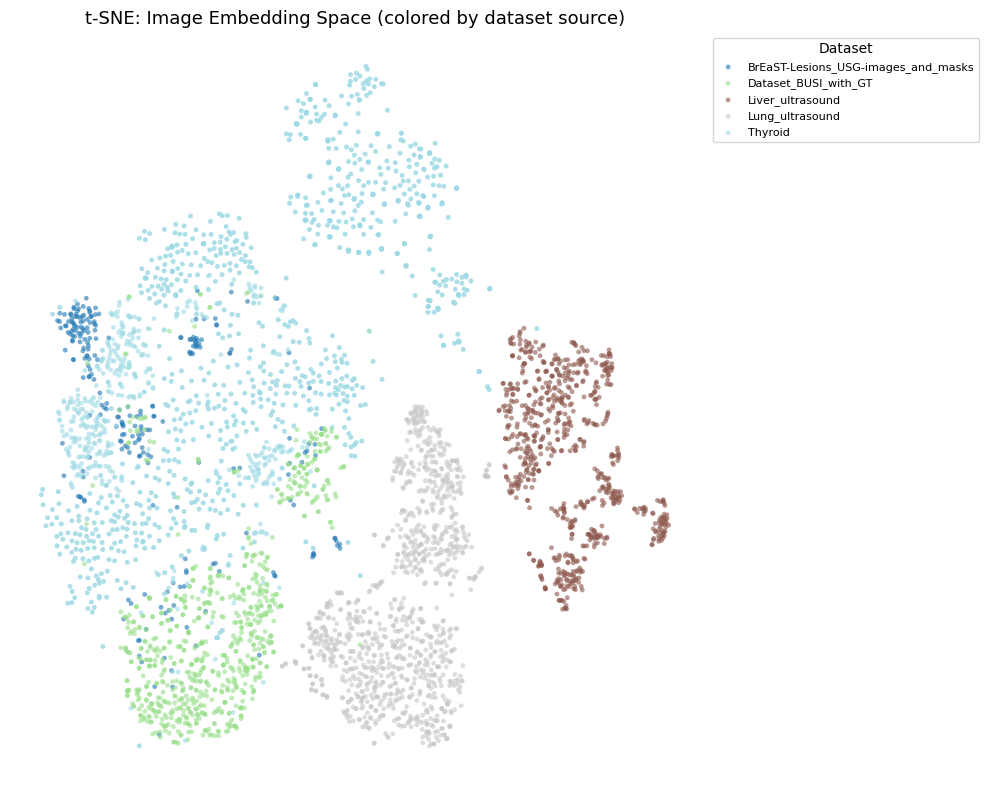

In [ ]:
# ── Build shared color map for all datasets (reused in Section 7) ──────────────
dataset_names = sorted(set(full_df['dataset']))
cmap_tab20    = plt.cm.get_cmap('tab20', len(dataset_names))
COLOR_MAP     = {name: cmap_tab20(i) for i, name in enumerate(dataset_names)}

# ── Run t-SNE ──────────────────────────────────────────────────────────────────
print(f'Running t-SNE on {len(img_embs_all):,} image embeddings...')
perp_img     = min(config['tsne_perplexity'], len(img_embs_all) - 1)
tsne_img     = TSNE(n_components=2, perplexity=perp_img,
                    random_state=config['random_seed'], n_jobs=-1)
img_tsne_xy  = tsne_img.fit_transform(img_embs_all)

# ── Scatter plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
for ds in dataset_names:
    idx = [i for i, d in enumerate(img_datasets_all) if d == ds]
    ax.scatter(img_tsne_xy[idx, 0], img_tsne_xy[idx, 1],
               c=[COLOR_MAP[ds]], label=ds, alpha=0.6, s=12, edgecolors='none')
ax.set_title('t-SNE: Image Embedding Space (colored by dataset source)', fontsize=13)
ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_image_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

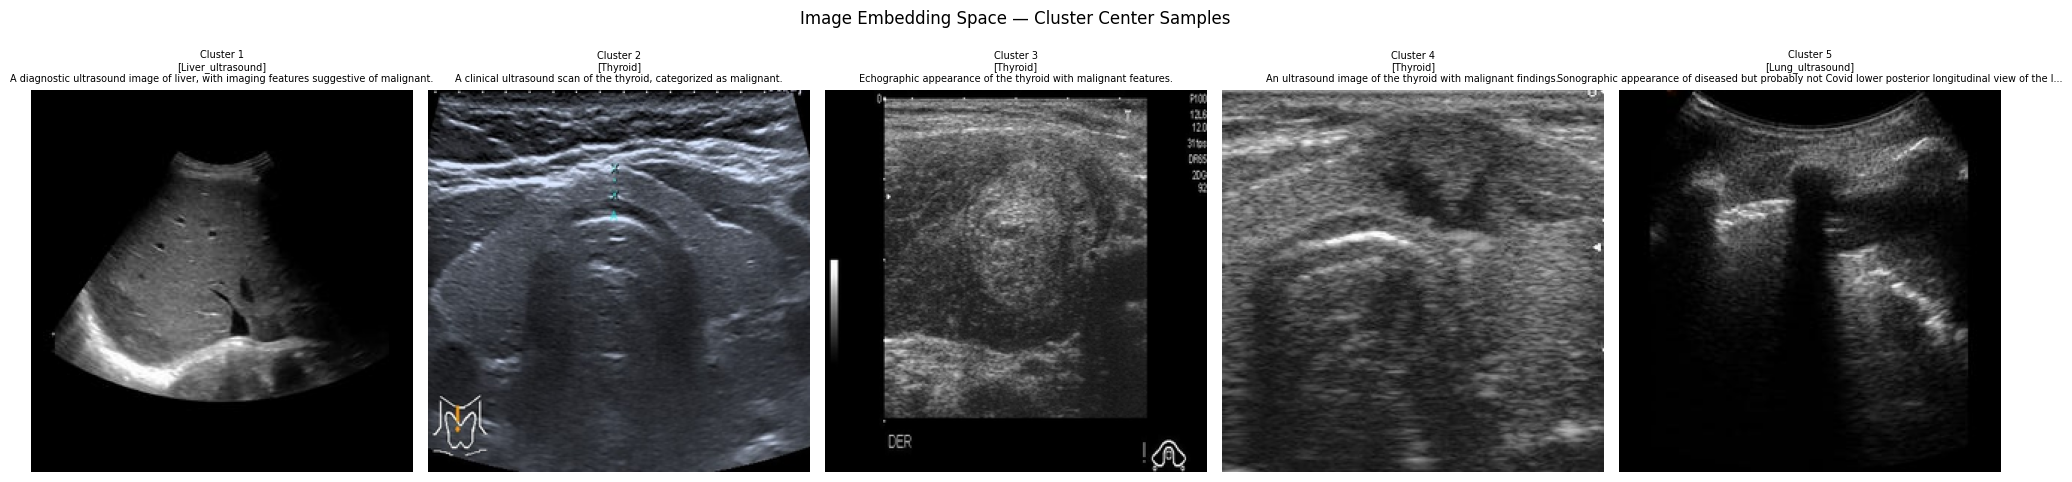

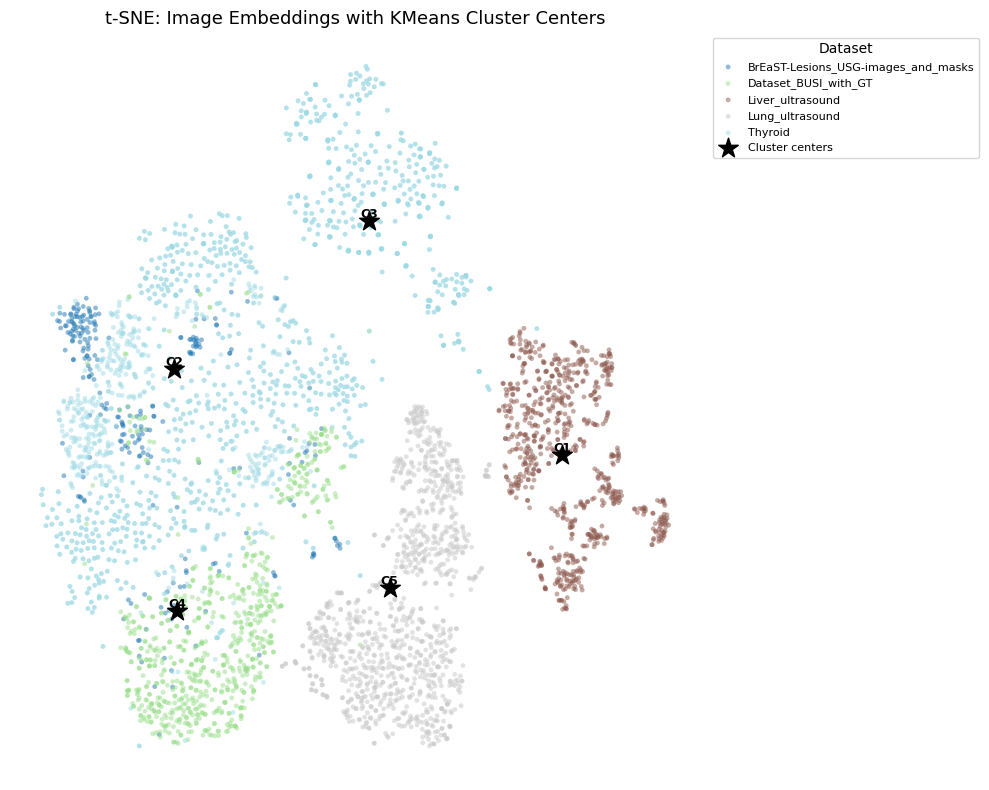

In [ ]:
# ── KMeans cluster centers → show nearest image + caption for each ─────────────
n_centers = config['n_cluster_centers']

kmeans_img  = KMeans(n_clusters=n_centers, random_state=config['random_seed'], n_init=10)
kmeans_img.fit(img_tsne_xy)
centers_img = kmeans_img.cluster_centers_  # (n_centers, 2)

dists_img   = cdist(centers_img, img_tsne_xy)  # (n_centers, N)
nearest_img = dists_img.argmin(axis=1)          # index in full_df for each center

fig, axes = plt.subplots(1, n_centers, figsize=(4 * n_centers, 5))
if n_centers == 1:
    axes = [axes]

for i, idx in enumerate(nearest_img):
    row = full_df.iloc[idx]
    img = Image.open(row['image_path']).convert('RGB')
    cap = row['caption'][:100] + ('...' if len(row['caption']) > 100 else '')
    axes[i].imshow(img)
    axes[i].set_title(f'Cluster {i+1}\n[{row["dataset"]}]\n{cap}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('Image Embedding Space — Cluster Center Samples', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('tsne_image_cluster_centers.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlay centers on the t-SNE plot
fig, ax = plt.subplots(figsize=(10, 8))
for ds in dataset_names:
    idx = [i for i, d in enumerate(img_datasets_all) if d == ds]
    ax.scatter(img_tsne_xy[idx, 0], img_tsne_xy[idx, 1],
               c=[COLOR_MAP[ds]], alpha=0.5, s=12, edgecolors='none', label=ds)
ax.scatter(centers_img[:, 0], centers_img[:, 1],
           c='black', marker='*', s=220, zorder=5, label='Cluster centers')
for i, c in enumerate(centers_img):
    ax.annotate(f'C{i+1}', c, fontsize=9, ha='center', va='bottom', fontweight='bold')
ax.set_title('t-SNE: Image Embeddings with KMeans Cluster Centers', fontsize=13)
ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 7 — t-SNE: Text Caption Embedding Space

Embed all **train split** captions with the pretrained CLIP text encoder.
Visualize in 2-D t-SNE colored by dataset source.
Print the nearest captions to each KMeans cluster center.

In [ ]:
# Load CLIP text encoder (pretrained, frozen — no training here)
text_encoder_vis = CLIPTextEncoder(
    clip_model_name     = config['clip_model_name'],
    projection_dim      = config['projection_dim'],
    freeze_text_encoder = True,
).to(device).eval()
print('CLIP text encoder loaded for caption embedding extraction.')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP text encoder loaded for caption embedding extraction.


In [ ]:
@torch.no_grad()
def extract_text_embeddings(text_encoder, captions, tokenizer, device, batch_size=64):
    """Embed a list of captions in batches. Returns numpy array (N, D)."""
    text_encoder.eval()
    all_embs = []
    for i in tqdm(range(0, len(captions), batch_size), desc='Extracting text embeddings'):
        batch     = captions[i : i + batch_size]
        ids, mask = tokenize_texts(batch, tokenizer, device=device)
        embs      = text_encoder(ids, mask).cpu().numpy()
        all_embs.append(embs)
    return np.concatenate(all_embs, axis=0)


train_captions     = train_df['caption'].tolist()
train_dataset_lbls = train_df['dataset'].tolist()

txt_embs = extract_text_embeddings(
    text_encoder_vis, train_captions, tokenizer, device
)
print(f'Extracted {len(txt_embs):,} text embeddings  shape={txt_embs.shape}')

Extracting text embeddings:   0%|          | 0/56 [00:00<?, ?it/s]

Extracted 3,579 text embeddings  shape=(3579, 256)


Running t-SNE on 3,579 text embeddings...


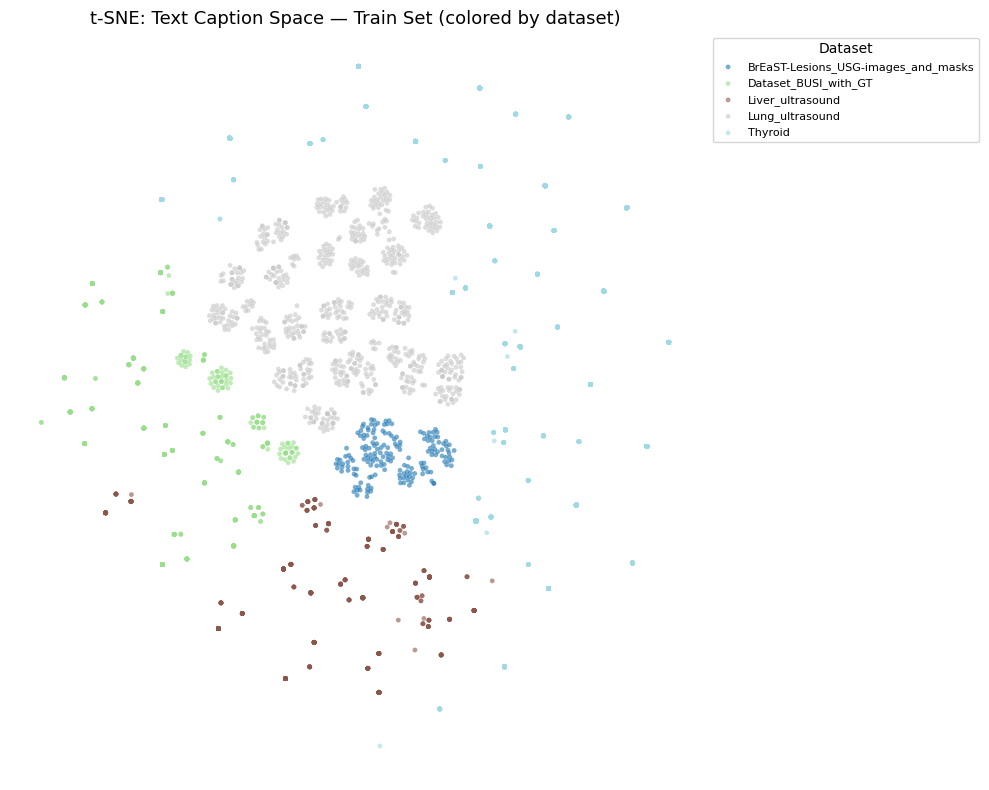

In [ ]:
print(f'Running t-SNE on {len(txt_embs):,} text embeddings...')
perp_txt    = min(config['tsne_perplexity'], len(txt_embs) - 1)
tsne_txt    = TSNE(n_components=2, perplexity=perp_txt,
                   random_state=config['random_seed'], n_jobs=-1)
txt_tsne_xy = tsne_txt.fit_transform(txt_embs)

fig, ax = plt.subplots(figsize=(10, 8))
for ds in dataset_names:
    idx = [i for i, d in enumerate(train_dataset_lbls) if d == ds]
    if idx:
        ax.scatter(txt_tsne_xy[idx, 0], txt_tsne_xy[idx, 1],
                   c=[COLOR_MAP[ds]], label=ds, alpha=0.6, s=12, edgecolors='none')
ax.set_title('t-SNE: Text Caption Space — Train Set (colored by dataset)', fontsize=13)
ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_text_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

Text Caption Cluster Centers  (top 3 nearest captions per cluster)

─────────────────────────────────────────────────────────────────
  Cluster 1:
    1. [Lung_ultrasound]
       lower posterior transverse view of the left lung evaluated by sonography. Normal findings. Conclusion: Healthy Lung.
    2. [Lung_ultrasound]
       lower posterior longitudinal view of the left lung evaluated by sonography. Normal findings. Conclusion: Healthy Lung.
    3. [Lung_ultrasound]
       lower posterior transverse view of the left lung evaluated by sonography. Normal findings. Conclusion: Healthy Lung.
─────────────────────────────────────────────────────────────────
  Cluster 2:
    1. [Liver_ultrasound]
       A diagnostic ultrasound image of liver, with imaging features suggestive of malignant.
    2. [Liver_ultrasound]
       A diagnostic ultrasound image of liver, with imaging features suggestive of malignant.
    3. [Liver_ultrasound]
       A diagnostic ultrasound image of liver, with imaging

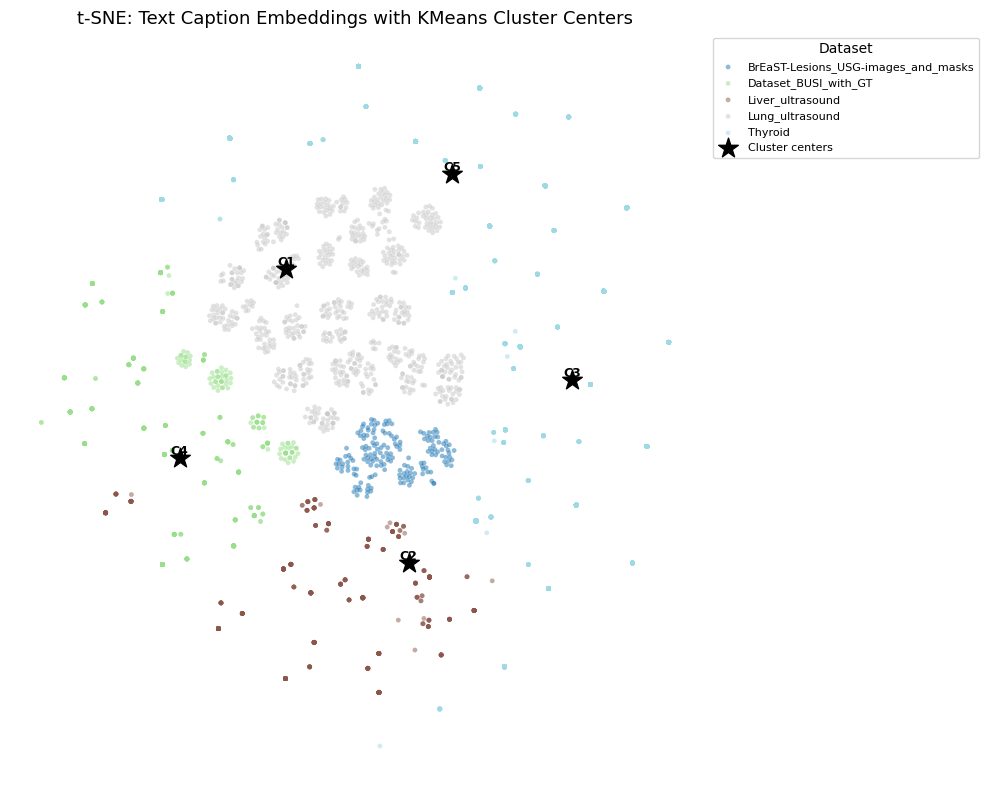

In [ ]:
n_centers = config['n_cluster_centers']
n_cap     = config['n_captions_per_cluster']

kmeans_txt  = KMeans(n_clusters=n_centers, random_state=config['random_seed'], n_init=10)
kmeans_txt.fit(txt_tsne_xy)
centers_txt = kmeans_txt.cluster_centers_

dists_txt = cdist(centers_txt, txt_tsne_xy)

print(f'Text Caption Cluster Centers  (top {n_cap} nearest captions per cluster)\n')
for i in range(n_centers):
    nearest = dists_txt[i].argsort()[:n_cap]
    print(f'{"─"*65}')
    print(f'  Cluster {i+1}:')
    for rank, idx in enumerate(nearest, 1):
        ds  = train_dataset_lbls[idx]
        cap = train_captions[idx]
        print(f'    {rank}. [{ds}]')
        print(f'       {cap[:120]}')
print(f'{"─"*65}')

# Overlay centers on the text t-SNE plot
fig, ax = plt.subplots(figsize=(10, 8))
for ds in dataset_names:
    idx = [i for i, d in enumerate(train_dataset_lbls) if d == ds]
    if idx:
        ax.scatter(txt_tsne_xy[idx, 0], txt_tsne_xy[idx, 1],
                   c=[COLOR_MAP[ds]], alpha=0.5, s=12, edgecolors='none', label=ds)
ax.scatter(centers_txt[:, 0], centers_txt[:, 1],
           c='black', marker='*', s=220, zorder=5, label='Cluster centers')
for i, c in enumerate(centers_txt):
    ax.annotate(f'C{i+1}', c, fontsize=9, ha='center', va='bottom', fontweight='bold')
ax.set_title('t-SNE: Text Caption Embeddings with KMeans Cluster Centers', fontsize=13)
ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Section 8 — Training Experiments

Four conditions compared by **mean paired cosine similarity** (alignment score) on the test set:

| Condition | Image Encoder | Text Encoder | MLP Heads |
|-----------|:-------------:|:------------:|:---------:|
| Baseline (no training) | frozen | frozen | random init |
| Exp 1: MLP only        | frozen | frozen | trained |
| Exp 2: MLP + Img Enc   | fine-tuned | frozen | trained |
| Exp 3: MLP + Txt Enc   | frozen | fine-tuned | trained |

All experiments use: AdamW optimizer · CosineAnnealingLR · best-checkpoint selection.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment infrastructure
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, dataloader, optimizer, tokenizer, device, epoch):
    model.train()
    total_loss = 0.0
    for batch_idx, (images, texts, _) in enumerate(dataloader):
        images = images.to(device)
        ids, mask = tokenize_texts(texts, tokenizer, device=device)
        optimizer.zero_grad()
        loss, _, _ = model(images, ids, mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 10 == 0 or batch_idx == len(dataloader) - 1:
            print(f'  [E{epoch+1}] Batch {batch_idx+1}/{len(dataloader)}'
                  f' | loss={loss.item():.4f}'
                  f' | temp={model.log_temperature.exp().item():.4f}')
    return total_loss / len(dataloader)


@torch.no_grad()
def validate_one_epoch(model, dataloader, tokenizer, device):
    model.eval()
    total_loss = 0.0
    for images, texts, _ in dataloader:
        images = images.to(device)
        ids, mask = tokenize_texts(texts, tokenizer, device=device)
        loss, _, _ = model(images, ids, mask)
        total_loss += loss.item()
    return total_loss / len(dataloader)


@torch.no_grad()
def compute_alignment_score(model, dataloader, tokenizer, device):
    """
    Alignment score = mean cosine similarity between matched (image, text) pairs.
    Both embeddings are L2-normalized, so dot product == cosine similarity.
    Range: [-1, 1].  Higher is better.
    """
    model.eval()
    all_img, all_txt = [], []
    for images, texts, _ in dataloader:
        images = images.to(device)
        ids, mask = tokenize_texts(texts, tokenizer, device=device)
        all_img.append(model.encode_image(images).cpu())
        all_txt.append(model.encode_text(ids, mask).cpu())
    img_embs = torch.cat(all_img)  # (N, D)
    txt_embs = torch.cat(all_txt)  # (N, D)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()  # diagonal

    all_sim   = img_embs @ txt_embs.T
    off_mask  = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()

    print(f'  Alignment score (paired):   {paired_sim:.4f}')
    print(f'  Cross-pair mean similarity: {cross_sim:.4f}')
    return paired_sim


def build_model(freeze_image=True, freeze_text=True):
    """
    Instantiate EchoCare_CLIP, load pretrained EchoCare image encoder weights,
    and apply freeze flags for each encoder.

    freeze_image=True  → only the MLP projection of the image side is trainable
    freeze_text=True   → only the MLP projection of the text side is trainable
    """
    img_enc = EchoCareImageEncoder(
        feature_size   = config['feature_size'],
        in_channels    = config['in_channels'],
        projection_dim = config['projection_dim'],
        freeze_encoder = freeze_image,
    )
    if os.path.exists(config['echocare_checkpoint']):
        img_enc.load_pretrained(config['echocare_checkpoint'], device=str(device))
    else:
        print('[WARNING] EchoCare checkpoint not found — random image encoder weights')

    txt_enc = CLIPTextEncoder(
        clip_model_name     = config['clip_model_name'],
        projection_dim      = config['projection_dim'],
        freeze_text_encoder = freeze_text,
    )

    model = EchoCare_CLIP(
        image_encoder    = img_enc,
        text_encoder     = txt_enc,
        init_temperature = config['init_temperature'],
    ).to(device)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'  Trainable: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)')
    return model


def train_experiment(model, train_loader, val_loader, checkpoint_path, label=''):
    """Full training loop. Returns (train_losses, val_losses)."""
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], weight_decay=config['weight_decay'],
    )
    scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['num_epochs']
    )
    train_losses, val_losses = [], []
    best_val      = float('inf')

    print(f'\n{"="*62}')
    print(f'  Training: {label}')
    print(f'{"="*62}')

    for epoch in range(config['num_epochs']):
        t_loss = train_one_epoch(model, train_loader, optimizer, tokenizer, device, epoch)
        v_loss = validate_one_epoch(model, val_loader, tokenizer, device)
        scheduler.step()
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        lr_now = scheduler.get_last_lr()[0]
        print(f'>>> Epoch {epoch+1:2d}/{config["num_epochs"]}'
              f'  Train={t_loss:.4f}  Val={v_loss:.4f}  LR={lr_now:.2e}')
        if v_loss < best_val:
            best_val = v_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  [Checkpoint] best val={best_val:.4f} → {checkpoint_path}')

    # Load best checkpoint before returning
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f'\nTraining complete.  Best val loss: {best_val:.4f}')
    return train_losses, val_losses


print('Experiment infrastructure defined.')

Experiment infrastructure defined.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline — pretrained backbones, random MLP heads, no training
# ─────────────────────────────────────────────────────────────────────────────
print('Building baseline model (no training)...')
model_baseline = build_model(freeze_image=True, freeze_text=True)

print('\nBaseline alignment score on test set:')
score_baseline = compute_alignment_score(model_baseline, test_loader, tokenizer, device)

Building baseline model (no training)...
Loaded EchoCare pretrained weights from '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth'


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

  Trainable: 5,114,881 / 188,502,521  (2.7%)

Baseline alignment score on test set:
  Alignment score (paired):   -0.0239
  Cross-pair mean similarity: -0.0251


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment 1 — Train MLP projection heads only (both encoders frozen)
# ─────────────────────────────────────────────────────────────────────────────
print('Building Exp 1 model (MLP heads only)...')
model_exp1 = build_model(freeze_image=True, freeze_text=True)

losses_exp1_train, losses_exp1_val = train_experiment(
    model_exp1, train_loader, val_loader,
    checkpoint_path = 'exp1_mlp_only_best.pth',
    label           = 'Exp 1: MLP Heads Only',
)

print('\nExp 1 alignment score on test set:')
score_exp1 = compute_alignment_score(model_exp1, test_loader, tokenizer, device)

Building Exp 1 model (MLP heads only)...
Loaded EchoCare pretrained weights from '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth'


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

  Trainable: 5,114,881 / 188,502,521  (2.7%)

  Training: Exp 1: MLP Heads Only
  [E1] Batch 1/223 | loss=2.9050 | temp=0.0700
  [E1] Batch 11/223 | loss=2.1623 | temp=0.0700
  [E1] Batch 21/223 | loss=2.0436 | temp=0.0700
  [E1] Batch 31/223 | loss=1.7469 | temp=0.0700
  [E1] Batch 41/223 | loss=1.9184 | temp=0.0700
  [E1] Batch 51/223 | loss=1.6919 | temp=0.0700
  [E1] Batch 61/223 | loss=1.7704 | temp=0.0700
  [E1] Batch 71/223 | loss=1.8405 | temp=0.0700
  [E1] Batch 81/223 | loss=1.9286 | temp=0.0700
  [E1] Batch 91/223 | loss=1.9934 | temp=0.0700
  [E1] Batch 101/223 | loss=1.4638 | temp=0.0700
  [E1] Batch 111/223 | loss=1.6269 | temp=0.0700
  [E1] Batch 121/223 | loss=1.4301 | temp=0.0700
  [E1] Batch 131/223 | loss=1.4959 | temp=0.0700
  [E1] Batch 141/223 | loss=1.8030 | temp=0.0700
  [E1] Batch 151/223 | loss=1.2811 | temp=0.0700
  [E1] Batch 161/223 | loss=1.6943 | temp=0.0700
  [E1] Batch 171/223 | loss=1.6550 | temp=0.0700
  [E1] Batch 181/223 | loss=1.8598 | temp=0.0700


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment 2 — Train MLP heads + Image Encoder (text encoder frozen)
# ─────────────────────────────────────────────────────────────────────────────
print('Building Exp 2 model (MLP + Image Encoder)...')
model_exp2 = build_model(freeze_image=False, freeze_text=True)

losses_exp2_train, losses_exp2_val = train_experiment(
    model_exp2, train_loader, val_loader,
    checkpoint_path = 'exp2_mlp_image_best.pth',
    label           = 'Exp 2: MLP + Image Encoder',
)

print('\nExp 2 alignment score on test set:')
score_exp2 = compute_alignment_score(model_exp2, test_loader, tokenizer, device)

Building Exp 2 model (MLP + Image Encoder)...
Loaded EchoCare pretrained weights from '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth'


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

  Trainable: 125,336,569 / 188,502,521  (66.5%)

  Training: Exp 2: MLP + Image Encoder
  [E1] Batch 1/223 | loss=2.8313 | temp=0.0700
  [E1] Batch 11/223 | loss=2.2976 | temp=0.0701
  [E1] Batch 21/223 | loss=2.1015 | temp=0.0701
  [E1] Batch 31/223 | loss=2.0740 | temp=0.0701
  [E1] Batch 41/223 | loss=2.3949 | temp=0.0701
  [E1] Batch 51/223 | loss=2.7807 | temp=0.0701
  [E1] Batch 61/223 | loss=2.0621 | temp=0.0701
  [E1] Batch 71/223 | loss=1.9929 | temp=0.0701
  [E1] Batch 81/223 | loss=2.4911 | temp=0.0701
  [E1] Batch 91/223 | loss=1.8072 | temp=0.0701
  [E1] Batch 101/223 | loss=2.0393 | temp=0.0701
  [E1] Batch 111/223 | loss=1.8248 | temp=0.0701
  [E1] Batch 121/223 | loss=2.1169 | temp=0.0701
  [E1] Batch 131/223 | loss=1.7809 | temp=0.0701
  [E1] Batch 141/223 | loss=2.2042 | temp=0.0702
  [E1] Batch 151/223 | loss=1.7724 | temp=0.0702
  [E1] Batch 161/223 | loss=2.4027 | temp=0.0702
  [E1] Batch 171/223 | loss=2.2115 | temp=0.0703
  [E1] Batch 181/223 | loss=2.4788 | temp

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment 3 — Train MLP heads + Text Encoder (image encoder frozen)
# ─────────────────────────────────────────────────────────────────────────────
print('Building Exp 3 model (MLP + Text Encoder)...')
model_exp3 = build_model(freeze_image=True, freeze_text=False)

losses_exp3_train, losses_exp3_val = train_experiment(
    model_exp3, train_loader, val_loader,
    checkpoint_path = 'exp3_mlp_text_best.pth',
    label           = 'Exp 3: MLP + Text Encoder',
)

print('\nExp 3 alignment score on test set:')
score_exp3 = compute_alignment_score(model_exp3, test_loader, tokenizer, device)

Building Exp 3 model (MLP + Text Encoder)...
Loaded EchoCare pretrained weights from '/content/drive/MyDrive/BMI702 Project/echocare_encoder.pth'


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

  Trainable: 68,280,833 / 188,502,521  (36.2%)

  Training: Exp 3: MLP + Text Encoder
  [E1] Batch 1/223 | loss=2.8028 | temp=0.0700
  [E1] Batch 11/223 | loss=2.0795 | temp=0.0700
  [E1] Batch 21/223 | loss=2.0019 | temp=0.0700
  [E1] Batch 31/223 | loss=1.5894 | temp=0.0700
  [E1] Batch 41/223 | loss=1.7449 | temp=0.0701
  [E1] Batch 51/223 | loss=2.1732 | temp=0.0701
  [E1] Batch 61/223 | loss=1.6369 | temp=0.0701
  [E1] Batch 71/223 | loss=2.0378 | temp=0.0701
  [E1] Batch 81/223 | loss=1.5645 | temp=0.0701
  [E1] Batch 91/223 | loss=1.7317 | temp=0.0701
  [E1] Batch 101/223 | loss=1.9607 | temp=0.0701
  [E1] Batch 111/223 | loss=1.7041 | temp=0.0701
  [E1] Batch 121/223 | loss=1.9882 | temp=0.0701
  [E1] Batch 131/223 | loss=2.0289 | temp=0.0701
  [E1] Batch 141/223 | loss=1.5574 | temp=0.0701
  [E1] Batch 151/223 | loss=1.6524 | temp=0.0701
  [E1] Batch 161/223 | loss=1.8442 | temp=0.0701
  [E1] Batch 171/223 | loss=1.7198 | temp=0.0702
  [E1] Batch 181/223 | loss=1.7545 | temp=0

---
## Section 9 — Results

**Alignment score** = mean cosine similarity between paired (image, text) test embeddings.  
Higher → image and text embeddings are closer in the shared latent space.

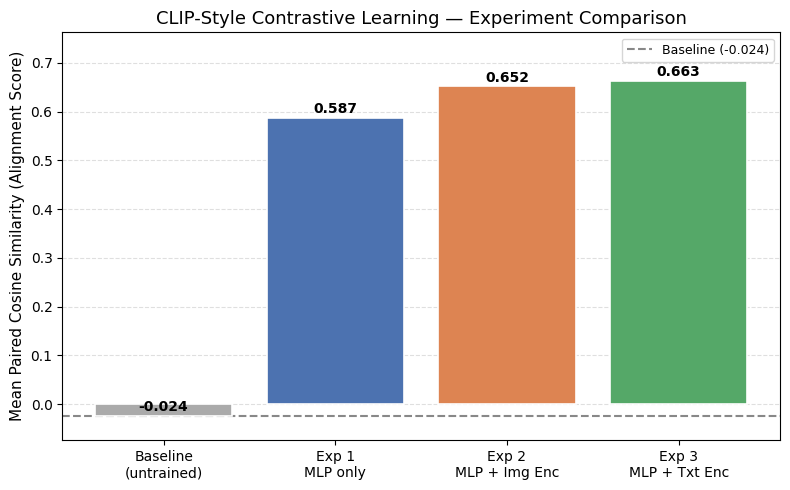


Summary:
  Baseline (untrained)        : -0.0239  (Δ=+0.0000 vs baseline)
  Exp 1 MLP only              : 0.5872  (Δ=+0.6110 vs baseline)
  Exp 2 MLP + Img Enc         : 0.6516  (Δ=+0.6754 vs baseline)
  Exp 3 MLP + Txt Enc         : 0.6631  (Δ=+0.6870 vs baseline)


In [ ]:
# ── Collect results ────────────────────────────────────────────────────────────
results = {
    'Baseline\n(untrained)': score_baseline,
    'Exp 1\nMLP only'      : score_exp1,
    'Exp 2\nMLP + Img Enc' : score_exp2,
    'Exp 3\nMLP + Txt Enc' : score_exp3,
}

labels = list(results.keys())
scores = list(results.values())

bar_colors = ['#aaaaaa', '#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color=bar_colors, edgecolor='white', linewidth=1.2, zorder=3)

# Baseline reference line
ax.axhline(y=score_baseline, color='#888888', linestyle='--', linewidth=1.5,
           label=f'Baseline ({score_baseline:.3f})', zorder=2)

# Annotate bar heights
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{score:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
    )

ax.set_ylabel('Mean Paired Cosine Similarity (Alignment Score)', fontsize=11)
ax.set_title('CLIP-Style Contrastive Learning — Experiment Comparison', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(min(0, min(scores) - 0.05), max(scores) * 1.15)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary:')
for label, score in results.items():
    lbl   = label.replace('\n', ' ')
    delta = score - score_baseline
    print(f'  {lbl:28s}: {score:.4f}  (Δ={delta:+.4f} vs baseline)')

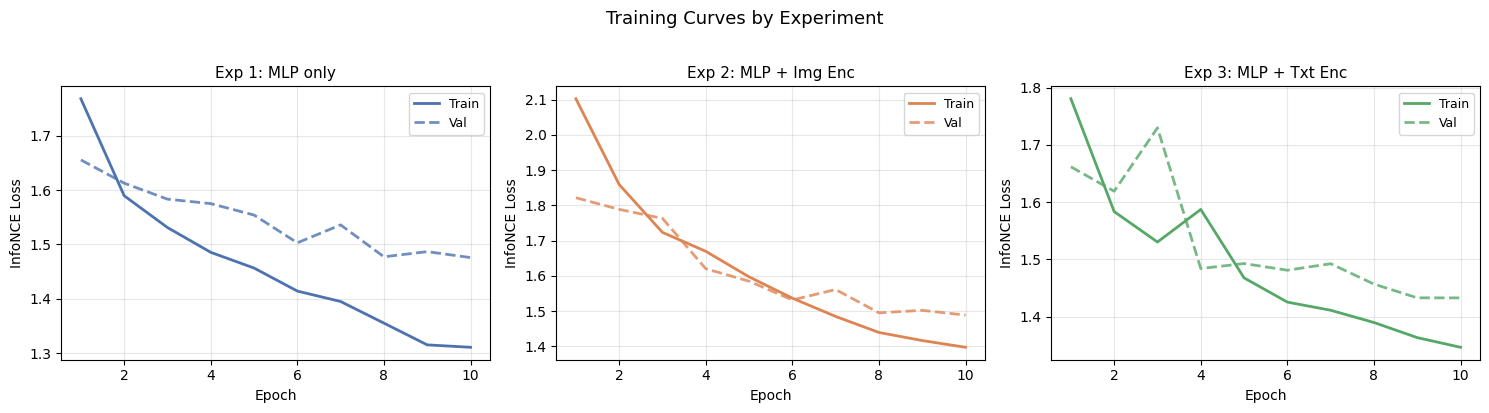

In [ ]:
# ── Training loss curves for all three experiments ─────────────────────────────
exp_curves = [
    ('Exp 1: MLP only',        losses_exp1_train, losses_exp1_val, '#4C72B0'),
    ('Exp 2: MLP + Img Enc',   losses_exp2_train, losses_exp2_val, '#DD8452'),
    ('Exp 3: MLP + Txt Enc',   losses_exp3_train, losses_exp3_val, '#55A868'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, t_losses, v_losses, color) in zip(axes, exp_curves):
    epochs = range(1, len(t_losses) + 1)
    ax.plot(epochs, t_losses, color=color, linewidth=2,               label='Train')
    ax.plot(epochs, v_losses, color=color, linewidth=2, linestyle='--',
            alpha=0.8, label='Val')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('InfoNCE Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves by Experiment', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import os
import torch

save_dir = "/content/drive/MyDrive/BMI702 Project/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Exp 1: Only MLP projection heads trained, both encoders frozen
torch.save(model_exp1.state_dict(),
    os.path.join(save_dir, "echocare_clip_mlp_heads_only.pt"))

# Exp 2: MLP heads + image encoder fine-tuned, text encoder frozen
torch.save(model_exp2.state_dict(),
    os.path.join(save_dir, "echocare_clip_mlp_and_image_encoder.pt"))

# Exp 3: MLP heads + text encoder fine-tuned, image encoder frozen
torch.save(model_exp3.state_dict(),
    os.path.join(save_dir, "echocare_clip_mlp_and_text_encoder.pt"))

print("All three models saved to:", save_dir)


model = build_model(freeze_image=True, freeze_text=True)  # match the architecture
model.load_state_dict(torch.load("saved_models/echocare_clip__mlp_heads_only__image_frozen__text_frozen.pt",
                                  map_location=device))
model.eval()


torch.save(model_exp1.image_proj.state_dict(), "image_mlp_head.pt")
torch.save(model_exp1.text_proj.state_dict(),  "text_mlp_head.pt")

model.image_proj.load_state_dict(torch.load(...))